In [1]:
pip install pandas numpy matplotlib seaborn plotly


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd               # For data manipulation and analysis
import numpy as np                # For numerical operations
import matplotlib.pyplot as plt    # For basic plotting
import seaborn as sns            # For advanced plotting
import datetime                   # For datetime operations
import plotly.express as px       # Optional: for interactive plots


In [3]:

# Read the dataset into a DataFrame
df = pd.read_csv('spotify_history.csv')
# Check the first few rows to make sure it's loaded correctly
df.head()



,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2J3n32GeLmMjwuAzyhcSNe,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,1oHxIPqJyvAYHy0PVrDU98,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,487OPlneJNni3NWC8SYqhW,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False
3,5IyblF777jLZj1vGHG2UD3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False
4,0GgAAB0ZMllFhbNc3mAodO,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False


In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   spotify_track_uri  149860 non-null  object
 1   ts                 149860 non-null  object
 2   platform           149860 non-null  object
 3   ms_played          149860 non-null  int64 
 4   track_name         149860 non-null  object
 5   artist_name        149860 non-null  object
 6   album_name         149860 non-null  object
 7   reason_start       149717 non-null  object
 8   reason_end         149743 non-null  object
 9   shuffle            149860 non-null  bool  
 10  skipped            149860 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 10.6+ MB


spotify_track_uri      0
ts                     0
platform               0
ms_played              0
track_name             0
artist_name            0
album_name             0
reason_start         143
reason_end           117
shuffle                0
skipped                0
dtype: int64

In [5]:
df.describe()


,ms_played
count,1.498600e+05
mean,1.283166e+05
std,1.178401e+05
min,0.000000e+00
25%,2.795000e+03
50%,1.388400e+05
75%,2.185070e+05
max,1.561125e+06


In [7]:
df['artist_name'].value_counts()


artist_name
The Beatles                13621
The Killers                 6878
John Mayer                  4855
Bob Dylan                   3814
Paul McCartney              2697
                           ...  
Chiquetere Band                1
DJ Kelvin El Sacamostro        1
T-Pain                         1
Sisqo                          1
Tiago PZK                      1
Name: count, Length: 4113, dtype: int64

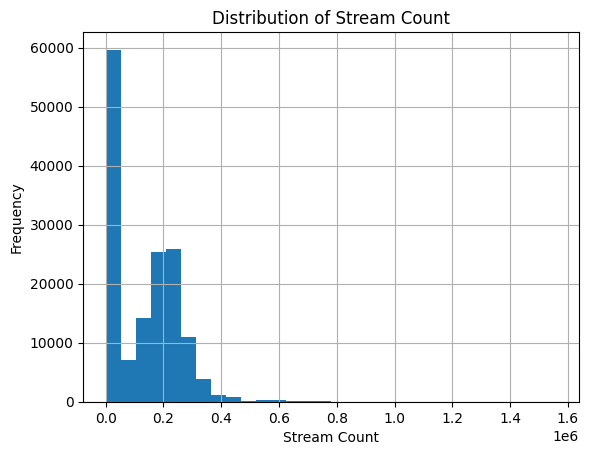

In [8]:
import matplotlib.pyplot as plt
df['ms_played'].hist(bins=30)
plt.title("Distribution of Stream Count")
plt.xlabel("Stream Count")
plt.ylabel("Frequency")
plt.show()


<Axes: xlabel='ms_played'>

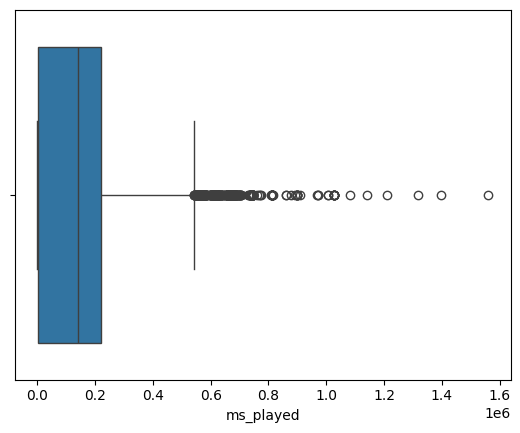

In [9]:
sns.boxplot(x=df['ms_played'])


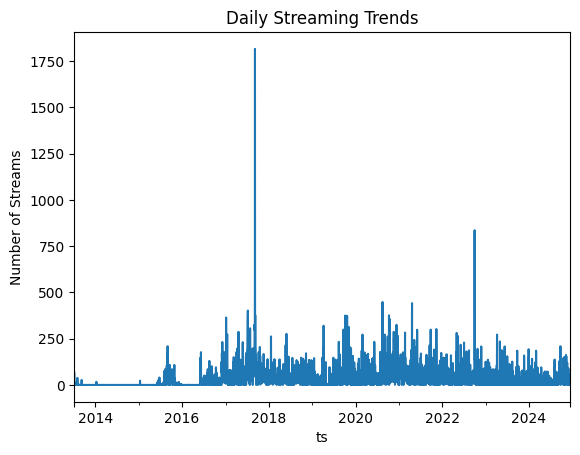

In [11]:
df['ts'] = pd.to_datetime(df['ts'])
df.set_index('ts').resample('D').size().plot()
plt.title("Daily Streaming Trends")
plt.ylabel("Number of Streams")
plt.show()


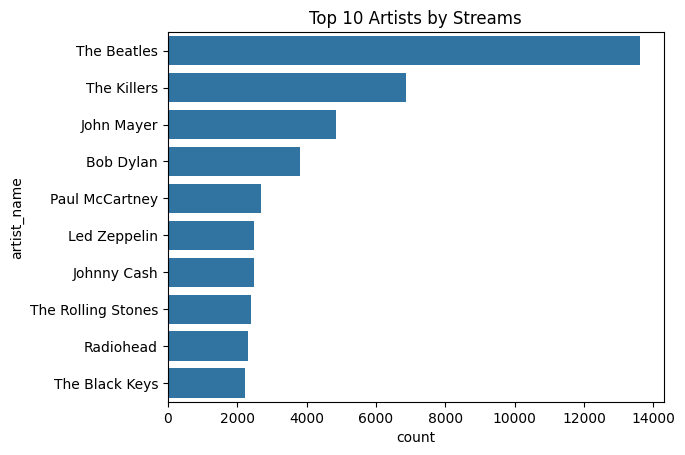

In [12]:
sns.countplot(y='artist_name', data=df, order=df['artist_name'].value_counts().iloc[:10].index)
plt.title("Top 10 Artists by Streams")
plt.show()


ValueError: could not convert string to float: '2J3n32GeLmMjwuAzyhcSNe'